# Random Forests — From Intuition to Code

So far, we've learned about **Decision Trees** — powerful, intuitive models that play “20 Questions” with our data.

But we also learned their biggest flaw: **Overfitting**. A single tree will memorize the training data, capturing every single piece of noise. They also suffer from **High Variance**, meaning simply changing a few rows of data can result in a completely different tree.

How do we fix this?

Instead of relying on one super-smart (but overconfident and rigid) tree, why not ask a **whole forest** of slightly dumber trees, and let them vote?

Welcome to **Ensemble Learning**, and its most famous algorithm: The **Random Forest**.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported!")

Libraries imported!


---
## 1. The Intuition: The Wisdom of Crowds

Imagine you are trying to guess how many jelly beans are in a giant jar.

- If you ask **one person** (a single Decision Tree), they might guess 5,000 or 500. Their guess might be way off because of their personal biases.
- But if you ask **1,000 independent people** and take the average of their guesses, that average is usually shockingly close to the real number.

This phenomenon is called the **"Wisdom of Crowds."**

A **Random Forest** is exactly this. It builds hundreds of independent Decision Trees and asks each of them to make a prediction.
- For **Classification** (e.g., Spam vs Not Spam): It takes a **majority vote** (like an election).
- For **Regression** (e.g., predicting House Prices): It takes the **average** of all the trees' predictions.

### Why does this work?
Because when you average together many independent models, the **noise cancels out**, leaving only the true signal. The individual trees might overfit, but the *forest* does not.

---
## 2. The Secret Sauce: "Random"

If you just build 100 Decision Trees on the exact same dataset using the exact same algorithm, you'll just get 100 identical trees. That defeats the purpose of voting!

To make the crowd wise, the individuals must be **diverse**. A Random Forest injects randomness in **two clever ways** to guarantee that every tree is unique.

### Step 1: Bootstrapping (Row Randomness)
When a Random Forest builds a new tree, it doesn't give the tree the full dataset. Instead, it creates a new mini-dataset of the same size by picking random rows from the original data **with replacement**.
- "With replacement" means a specific row can be picked multiple times, and some rows might not be picked at all.
- Typically, each tree only sees about **63% of the unique rows**. The remaining 37% are called **Out-Of-Bag (OOB)** samples.
- This ensures every tree is trained on slightly different data.

### Step 2: Feature Randomness (Column Randomness)
In a normal Decision Tree, at every split, the algorithm looks at **every single feature** (e.g., all 57 words in our spam dataset) to find the absolute best question to ask.

In a Random Forest, at every single split, the tree is only allowed to look at a **random subset of features**.
- Usually, it only sees $\sqrt{\text{Total Features}}$. (So if you have 100 features, each split can only choose from 10 random features).
- Why? Because if there is one extremely strong feature (e.g., the word "Viagra" in spam emails), *every single tree* would use that feature at the top root node, making the trees highly correlated.
- By hiding features, the algorithm is forced to explore weaker features, uncovering hidden patterns and making the trees highly diverse.

---

**Bagging = Bootstraps + Aggregation**.
A Random Forest is effectively an ensemble of Decision Trees trained using **Bagging** *plus* Feature Randomness.

---
## 3. From Scratch: Building the Forest

Let's see this in action by building the bootstrap and feature sampling mechanics from scratch! We will use `DecisionTreeClassifier` from `sklearn.tree` as our base tree to save space, but we will write the Forest logic ourselves.

In [5]:
from sklearn.tree import DecisionTreeClassifier
from collections import Counter

class MyRandomForest:
    def __init__(self, n_estimators=100, max_depth=None, max_features='log2', min_samples_split=2):
        self.n_estimators = n_estimators      # How many trees in the forest?
        self.max_depth = max_depth            # Max depth of each tree
        self.max_features = max_features      # How many features to look at per split ('sqrt' or 'log2')
        self.min_samples_split = min_samples_split
        self.trees = []                       # Where we'll store our trained trees

    def _bootstrap_sample(self, X, y):
        """
        Step 1: Row Randomness.
        Randomly pick rows with replacement.
        """
        n_samples = X.shape[0]
        # Generate random indices with replacement
        idxs = np.random.choice(n_samples, size=n_samples, replace=True)
        return X[idxs], y[idxs]

    def fit(self, X, y):
        """
        Train the Forest.
        """
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, pd.Series):
            y = y.values
            
        self.trees = []
        # Build n_estimators completely independent trees!
        for _ in range(self.n_estimators):
            # 1. Get a random subset of the data (Bootstrap)
            X_sample, y_sample = self._bootstrap_sample(X, y)
            
            # 2. Initialize a base Decision Tree
            # Notice the max_features parameter! That handles Step 2 (Column Randomness)
            tree = DecisionTreeClassifier(
                max_depth=self.max_depth, 
                max_features=self.max_features,
                min_samples_split=self.min_samples_split
            )
            
            # 3. Train the tree on its specific biased dataset
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
            
        return self

    def predict(self, X):
        """
        Predict by taking a majority vote from all trees.
        """
        if isinstance(X, pd.DataFrame):
            X = X.values
            
        # Ask every single tree for its prediction
        # Shape will be (n_estimators, n_samples)
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        
        # Calculate majority vote for each sample
        # We swap the axes to iterate column by column (sample by sample)
        tree_preds = np.swapaxes(tree_preds, 0, 1)
        
        # For each row (sample), find the most common prediction among all trees
        majority_votes = [Counter(sample_preds).most_common(1)[0][0] for sample_preds in tree_preds]
        
        return np.array(majority_votes)

print("MyRandomForest defined!")

MyRandomForest defined!


---
## 4. Why Use Random Forests? The Pros and Cons

### Benefits
1. **Highly Accurate**: RF is famously one of the best performing out-of-the-box algorithms for tabular (spreadsheet) data. It is very hard to beat.
2. **Resistant to Overfitting**: Because it takes an average/vote across hundreds of independent models, the random noise that a single tree would memorize gets effectively canceled out.
3. **Zero Preprocessing Needed**: Like individual trees, Random Forests don't care about scaling, normalization, or standardization. They handle non-linear relationships straight away.
4. **Feature Importance**: Random Forests tell you exactly which features were most useful in making the split across all trees. This is incredibly valuable for business insights.
5. **Missing Values & Outliers**: Very robust against outliers.

### Bottlenecks & Drawbacks
1. **Black-Box Model**: You lose the beautiful interpretability of a single Decision Tree. You can't print out 500 trees and explain the flowchart to a CEO.
2. **Memory Hungry**: If you train an ensemble of 1,000 deep trees, saving the model can take gigabytes of RAM/Disk space.
3. **Slow Prediction Time**: To predict a single test row, that row must be passed down every single one of the 1,000 trees before taking a vote. Unsuitable for nanosecond-latency requirements.
4. **Poor Extrapolation**: If regression data goes outside the bounds of the training data, Random Forests cannot predict a trend line. They can only predict values they've seen before.

---
## 5. Seeing is Believing: Generating a Complex Dataset

We need a complex, non-linear dataset. We'll use sklearn's `make_circles` which creates an inner circle of Class 1 surrounded by an outer ring of Class 0. 
A single straight line (Logistic Regression) absolutely **fails** here. Let's see how trees handle it.

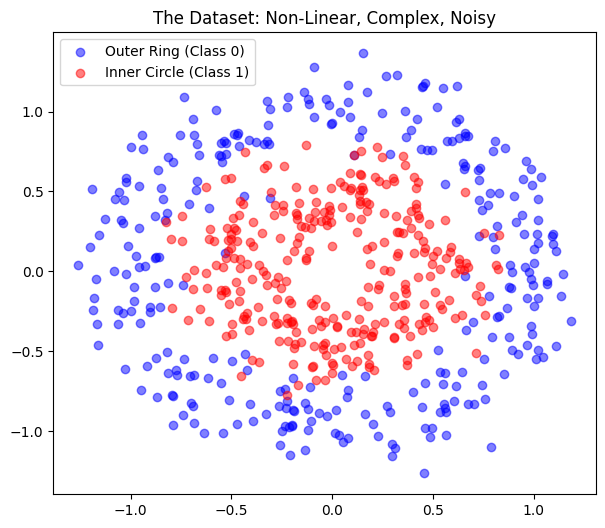

In [6]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# 1. Generate non-linear 'circles' data with noise
X, y = make_circles(n_samples=600, noise=0.15, factor=0.5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.figure(figsize=(7, 6))
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='blue', alpha=0.5, label='Outer Ring (Class 0)')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='red', alpha=0.5, label='Inner Circle (Class 1)')
plt.title("The Dataset: Non-Linear, Complex, Noisy")
plt.legend()
plt.show()

---
## 6. Training: Single Tree vs. The Forest

Let's compare a single unconstrained Decision Tree against our custom Random Forest and Scikit-Learn's Random Forest.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Single Decision Tree (Will probably overfit!)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)

# 2. Our Custom MyRandomForest (100 trees)
mrf = MyRandomForest(n_estimators=100, max_features='log2', max_depth=None)
mrf.fit(X_train, y_train)
mrf_preds = mrf.predict(X_test)

# 3. Scikit-Learn Official Random Forest (100 trees)
rf = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("=" * 40)
print("         TEST ACCURACY")
print("=" * 40)
print(f"Single Decision Tree:      {accuracy_score(y_test, dt_preds):.2%}")
print(f"My Random Forest:        {accuracy_score(y_test, mrf_preds):.2%}")
print(f"Sklearn Random Forest:     {accuracy_score(y_test, rf_preds):.2%}")
print("=" * 40)

         TEST ACCURACY
Single Decision Tree:      93.33%
My Random Forest:        94.44%
Sklearn Random Forest:     93.89%


Notice the massive jump in accuracy! The single tree struggled with the noise. The forest averaged the noise out.

---
## 7. The Ultimate Proof: Visualizing the Decision Boundary

This is where the difference between a Tree and a Forest becomes undeniable.
1. Look at how **jagged, rigid, and detailed** the Single Tree's boundary is. It is stretching out in weird directions to perfectly capture single outliers. That is **Overfitting**.
2. Look at how **smooth** the Random Forest boundary is. Because it takes an average, the rigid square boundaries blend together into smooth, generalized curves.

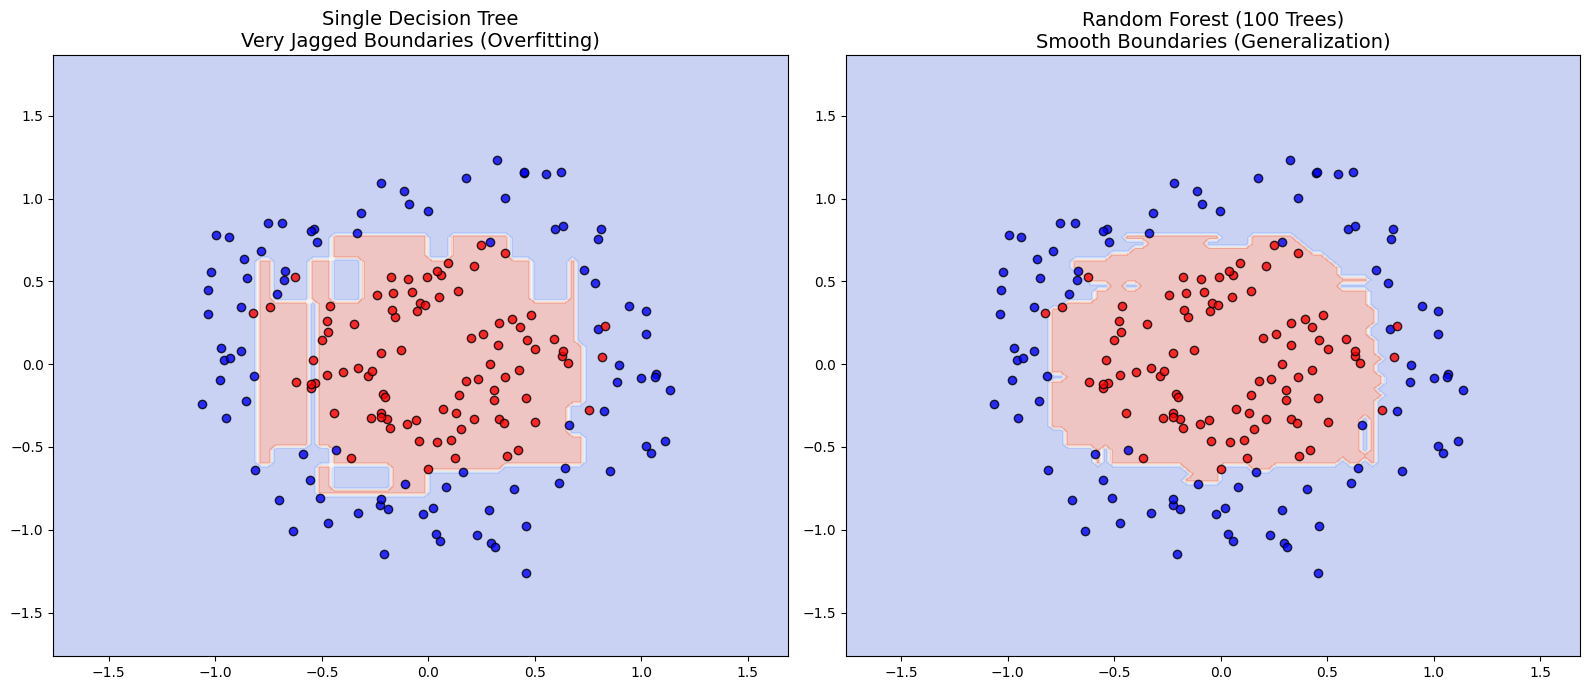

In [8]:
# Setup meshgrid
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - .5, X[:, 0].max() + .5, 100),
                     np.linspace(X[:, 1].min() - .5, X[:, 1].max() + .5, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Predict the grid
Z_dt = dt.predict(grid_points).reshape(xx.shape)
Z_rf = rf.predict(grid_points).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left Plot: Single Tree ---
axes[0].contourf(xx, yy, Z_dt, alpha=0.3, cmap='coolwarm')
axes[0].scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], c='blue', edgecolors='k', alpha=0.8)
axes[0].scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], c='red', edgecolors='k', alpha=0.8)
axes[0].set_title(f"Single Decision Tree\nVery Jagged Boundaries (Overfitting)", fontsize=14)

# --- Right Plot: Random Forest ---
axes[1].contourf(xx, yy, Z_rf, alpha=0.3, cmap='coolwarm')
axes[1].scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], c='blue', edgecolors='k', alpha=0.8)
axes[1].scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], c='red', edgecolors='k', alpha=0.8)
axes[1].set_title(f"Random Forest (100 Trees)\nSmooth Boundaries (Generalization)", fontsize=14)

plt.tight_layout()
plt.show()

---
## 8. Feature Importance: The Best Side-Effect

Because a Random Forest tries so many random combinations of features across thousands of splits, it naturally tracks **which features successfully reduced impurity (Gini/Entropy) the most**.

This allows us to extract **Feature Importance** — ranking exactly which columns drove the model's decisions.

/tmp/ipykernel_1332119/1245375429.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


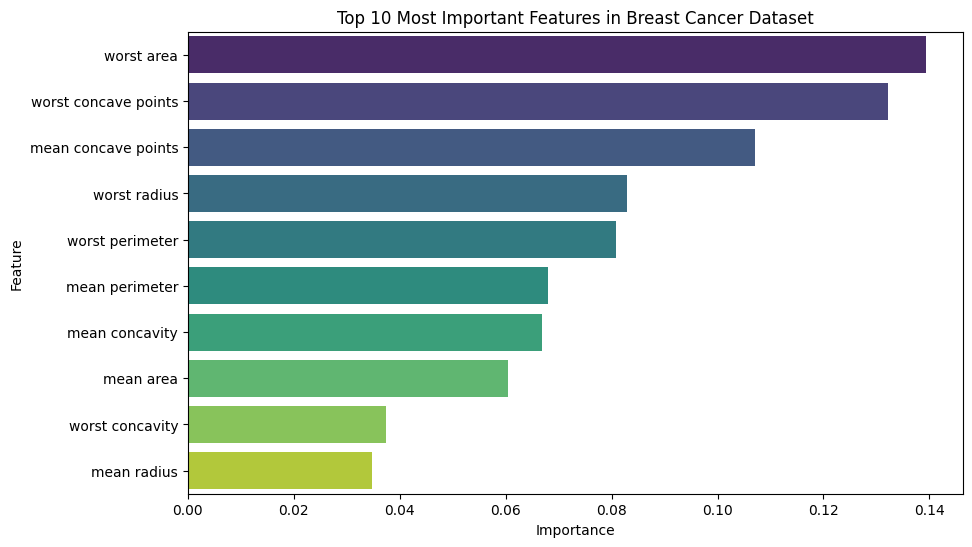

In [9]:
# Train on a dataset with named features (like a dataframe)
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df_X = pd.DataFrame(data.data, columns=data.feature_names)
df_y = data.target

# Train Random Forest
rf_import = RandomForestClassifier(n_estimators=100, random_state=42)
rf_import.fit(df_X, df_y)

# Extract and sort Feature Importances
importances = rf_import.feature_importances_
# Create a DataFrame for nice plotting (top 10)
feat_df = pd.DataFrame({'Feature': df_X.columns, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Top 10 Most Important Features in Breast Cancer Dataset')
plt.show()

Even though we lost the ability to print out a single flowchart, we **gained** the ability to tell stakeholders: *"Hey, across 100 simulations, 'worst perimeter' and 'worst concave points' were consistently the biggest predictors of cancer."

---
## 9. About Hyperparameters

Random Forests are widely beloved because **they rarely need extensive hyperparameter tuning**. The default settings in `scikit-learn` are incredibly optimized. However, if you do want to tune them:

| Hyperparameter | What it Does | Standard Values |
|---|---|---|
| `n_estimators` | Number of trees to build. More trees = smoother boundaries, but slower training. | `100`, `200`, `500` |
| `max_depth` | Limit the maximum depth of the base trees. | `None` (let them grow), `10`, `20` |
| `max_features` | The subset of features available at each split. | `'sqrt'`, `'log2'` |
| `n_jobs` | Number of CPU cores to use. Set to `-1` to use all cores (makes training much faster). | `-1` |

---